##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

Loading ViT-Small model (384-dimensional) and dataset...
Extracting features for exactly 10 Cats and 10 Dogs...

Running K-Means clustering (n=2)...

--- Clustering Results ---
Predicted Clusters: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
Actual Labels:      [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
Clustering Accuracy: 100.0%


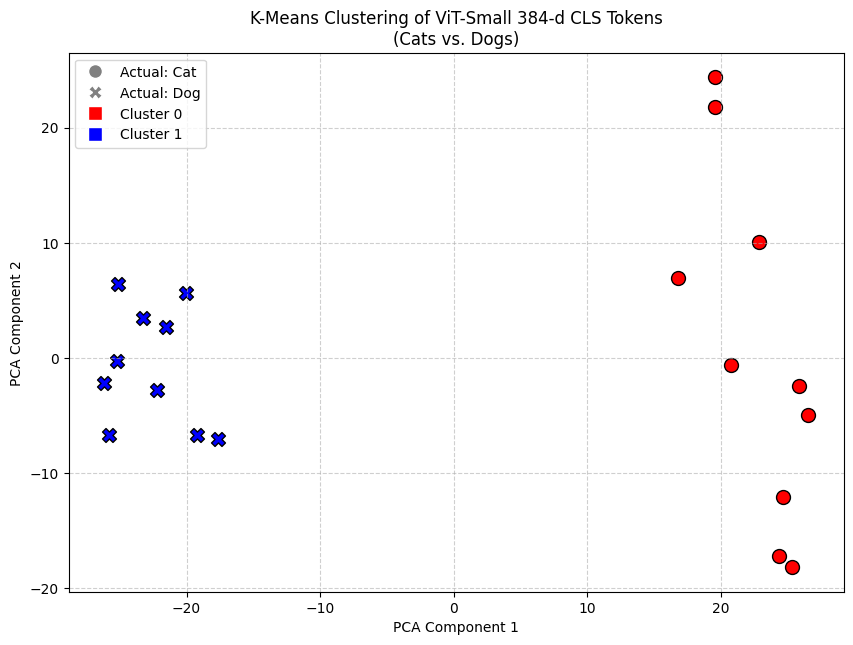

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import timm
from torchvision import datasets, transforms
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

def main():
    print("Loading ViT-Small model (384-dimensional) and dataset...")
    
    # 1. Setup Data and Model
    device = torch.device("cpu")
    
    # Using timm to get ViT-Small (which has exactly 384 dimensions)
    # num_classes=0 removes the classification head to give us the raw CLS token
    model = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=0)
    model = model.to(device)
    model.eval()

    # Transform for ViT: Resize to 224x224 and normalize
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # Load Oxford-IIIT Pet Dataset
    dataset = datasets.OxfordIIITPet(root='./data', download=True, transform=transform)

    # 2. Extract 384-dimensional [CLS] Tokens for exactly 10 Cats and 10 Dogs
    num_images = 20
    cls_tokens = []
    true_labels = []

    cats_collected = 0
    dogs_collected = 0
    target_per_class = 10

    print(f"Extracting features for exactly {target_per_class} Cats and {target_per_class} Dogs...")
    with torch.no_grad():
        for i in range(len(dataset)):
            if cats_collected == target_per_class and dogs_collected == target_per_class:
                break # Stop when we have 20 mixed images
                
            img, label = dataset[i]
            
            # Oxford Pet labels: 0-11 are Cats, 12-36 are Dogs
            is_cat = label < 12
            
            if is_cat and cats_collected < target_per_class:
                binary_label = 0 # 0 for Cat
                cats_collected += 1
            elif not is_cat and dogs_collected < target_per_class:
                binary_label = 1 # 1 for Dog
                dogs_collected += 1
            else:
                continue # Skip if we already have enough of this class
            
            img = img.unsqueeze(0).to(device)
            
            # timm models with num_classes=0 directly output the pooled [CLS] token
            cls_output = model(img).numpy()
            
            cls_tokens.append(cls_output.flatten())
            true_labels.append(binary_label)

    cls_tokens = np.array(cls_tokens)
    true_labels = np.array(true_labels)
    


    # 3. K-Means Clustering
    print("\nRunning K-Means clustering (n=2)...")
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    predicted_clusters = kmeans.fit_predict(cls_tokens)

    # 4. Evaluation and Output
    print("\n--- Clustering Results ---")
    print(f"Predicted Clusters: {predicted_clusters}")
    print(f"Actual Labels:      {true_labels}")
   
    
    # Calculate accuracy
    match_accuracy = np.mean(predicted_clusters == true_labels)
    inverted_accuracy = np.mean(predicted_clusters == (1 - true_labels))
    best_accuracy = max(match_accuracy, inverted_accuracy) * 100
    print(f"Clustering Accuracy: {best_accuracy:.1f}%")

    # 5. Visualization using PCA
    pca = PCA(n_components=2)
    reduced_data = pca.fit_transform(cls_tokens)

    plt.figure(figsize=(10, 7))
    
    for i in range(num_images):
        color = 'red' if predicted_clusters[i] == 0 else 'blue'
        marker = 'o' if true_labels[i] == 0 else 'X' # Circle = Cat, X = Dog
        
        plt.scatter(reduced_data[i, 0], reduced_data[i, 1], 
                    c=color, marker=marker, edgecolors='k', s=100)

    # Create a custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Actual: Cat', markerfacecolor='grey', markersize=10),
        Line2D([0], [0], marker='X', color='w', label='Actual: Dog', markerfacecolor='grey', markersize=10),
        Line2D([0], [0], marker='s', color='w', label='Cluster 0', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='s', color='w', label='Cluster 1', markerfacecolor='blue', markersize=10)
    ]

    plt.legend(handles=legend_elements, loc='best')
    plt.title("K-Means Clustering of ViT-Small 384-d CLS Tokens\n(Cats vs. Dogs)")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

if __name__ == "__main__":
    main()

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [ ]:
import torch
import requests
import io
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification

def main():
    device = torch.device("cpu")
    
    
    #Load specific DINOv2 Model ID
    model_id = "facebook/dinov2-small-imagenet1k-1-layer"
    print(f"Loading model and processor: '{model_id}'...")
    
    processor = AutoImageProcessor.from_pretrained(model_id)
    model = AutoModelForImageClassification.from_pretrained(model_id).to(device)
    model.eval()


    # Find an image online (ImageNet-1k class)
    img_url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
    print(f"\nFetching image from URL: {img_url}")
    
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
    response = requests.get(img_url, headers=headers)
    
   
    response.raise_for_status()
    
    # Download and open the image safely
    raw_image = Image.open(io.BytesIO(response.content)).convert("RGB")
    
    
    # INFERENCE: Map visual features to ImageNet categories
    print("Running DINOv2 inference...")
    
    inputs = processor(images=raw_image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        
    logits = outputs.logits
    predicted_class_idx = logits.argmax(-1).item()
    predicted_label = model.config.id2label[predicted_class_idx]
    

    # OUTPUT RESULTS
    print("\n--- Classification Results ---")
    print(f"Predicted Class Index: {predicted_class_idx}")
    print(f"Predicted Label:       {predicted_label}")
    print("------------------------------")
    
    # In Jupyter/Colab, .show() often doesn't pop up a window.
    # To see the image, you can just type 'raw_image' in a new notebook cell and run it!
    # raw_image.show()

if __name__ == "__main__":
    main()

Loading model and processor: 'facebook/dinov2-small-imagenet1k-1-layer'...


Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]


Fetching image from URL: https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg
Running DINOv2 inference...

--- Classification Results ---
Predicted Class Index: 258
Predicted Label:       Samoyed, Samoyede
------------------------------
